# HDBSCAN Clustering Demo

This notebook demonstrates the HDBSCAN clustering algorithm implemented in Rust and exposed via `datascienceutils`.

HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) is a powerful clustering algorithm that extends DBSCAN by converting it into a hierarchical clustering algorithm, and then extracting a flat clustering based on the stability of clusters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import datascienceutils as dsu
from sklearn.datasets import make_blobs, make_moons

# Configure plotting
plt.style.use('seaborn-v0_8')
np.random.seed(42)

## 1. Clustering Blobs

First, let's cluster a simple dataset of blobs with varying densities.

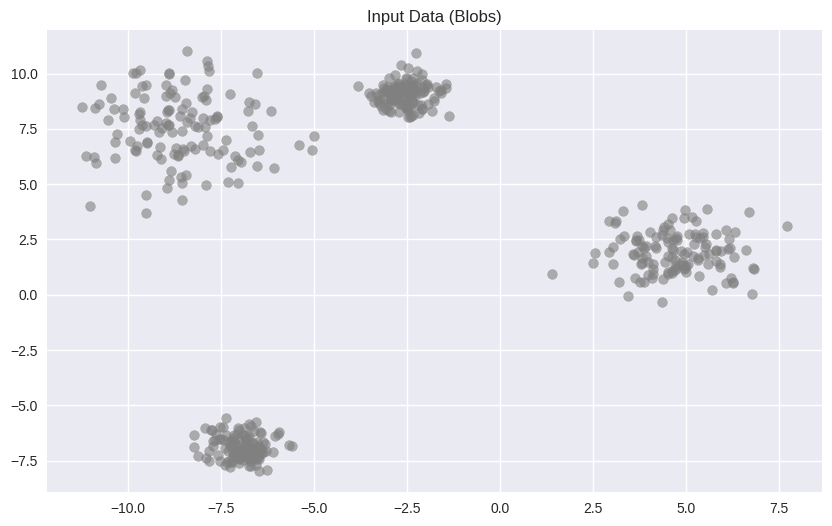

In [2]:
# Generate sample data
X_blobs, y_blobs = make_blobs(n_samples=500, centers=4, cluster_std=[0.5, 1.0, 0.5, 1.5], random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=50, alpha=0.6, c='gray')
plt.title("Input Data (Blobs)")
plt.show()

In [3]:
# Run HDBSCAN
min_cluster_size = 20
result = dsu.hdbscan_cluster(X_blobs, min_cluster_size)

print(f"Found {result.n_clusters} clusters")
print(f"Number of noise points: {np.sum(np.array(result.labels) == -1)}")

Found 4 clusters
Number of noise points: 5


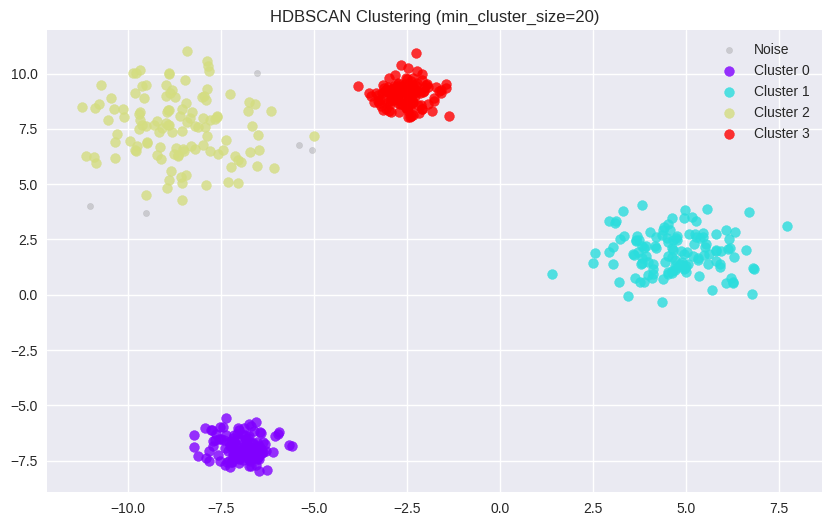

In [4]:
# Visualize results
labels = np.array(result.labels)

plt.figure(figsize=(10, 6))
# Plot noise
noise_mask = labels == -1
plt.scatter(X_blobs[noise_mask, 0], X_blobs[noise_mask, 1], c='gray', s=20, alpha=0.3, label='Noise')

# Plot clusters
unique_labels = set(labels)
unique_labels.discard(-1)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(sorted(unique_labels), colors):
    class_member_mask = (labels == k)
    plt.scatter(X_blobs[class_member_mask, 0], X_blobs[class_member_mask, 1], 
                color=col, s=50, alpha=0.8, label=f'Cluster {k}')

plt.title(f"HDBSCAN Clustering (min_cluster_size={min_cluster_size})")
plt.legend()
plt.show()

## 2. Clustering Moons

Now let's try a more complex shape: two interleaving half circles (moons).

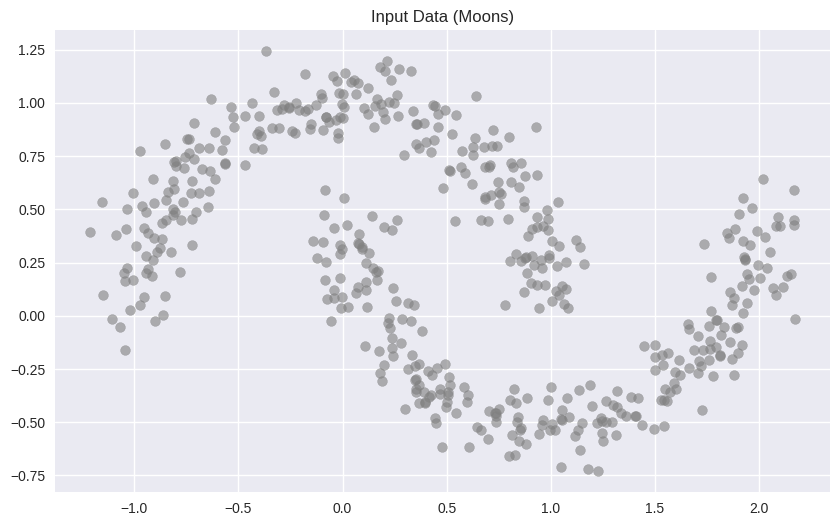

In [5]:
X_moons, _ = make_moons(n_samples=500, noise=0.1, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], s=50, alpha=0.6, c='gray')
plt.title("Input Data (Moons)")
plt.show()

In [6]:
# Run HDBSCAN
min_cluster_size = 10
result_moons = dsu.hdbscan_cluster(X_moons, min_cluster_size)

print(f"Found {result_moons.n_clusters} clusters")

Found 2 clusters


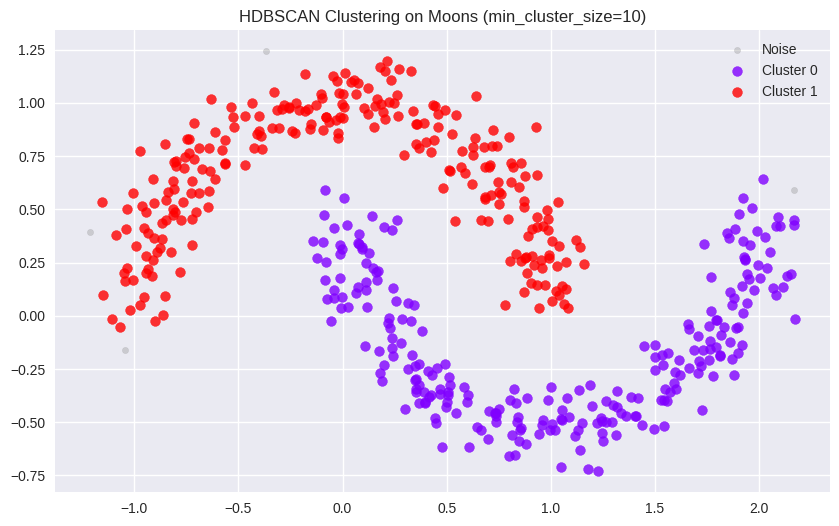

In [7]:
# Visualize results
labels_moons = np.array(result_moons.labels)

plt.figure(figsize=(10, 6))
# Plot noise
noise_mask = labels_moons == -1
plt.scatter(X_moons[noise_mask, 0], X_moons[noise_mask, 1], c='gray', s=20, alpha=0.3, label='Noise')

# Plot clusters
unique_labels = set(labels_moons)
unique_labels.discard(-1)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(sorted(unique_labels), colors):
    class_member_mask = (labels_moons == k)
    plt.scatter(X_moons[class_member_mask, 0], X_moons[class_member_mask, 1], 
                color=col, s=50, alpha=0.8, label=f'Cluster {k}')

plt.title(f"HDBSCAN Clustering on Moons (min_cluster_size={min_cluster_size})")
plt.legend()
plt.show()